In [1]:
from file_reader import CSVReader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn import svm
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from collections import Counter
import re
from matplotlib import pyplot as plt
import seaborn as sns # for nice visualizations


reader = CSVReader()
recordings = reader.get_data_files_as_df()


def convert_gyro_data():
    need_gyro_conversion = ["lennart", "maximilian"]
    for recording in recordings:
        if recording["name"] in need_gyro_conversion:
            recording["data"]["gyro_x"] = np.deg2rad(recording["data"]["gyro_x"])
            recording["data"]["gyro_y"] = np.deg2rad(recording["data"]["gyro_y"])
            recording["data"]["gyro_z"] = np.deg2rad(recording["data"]["gyro_z"])


def split_recordings_to_train_test(whole_set):
    training, test = train_test_split(
        whole_set,
        test_size=0.2,
        stratify=[
            f"{r['activity']}_{r['name']}_{r['sensor_placement']}_{r['sample_rate']}"
            for r in recordings
        ],
        random_state=42,
    )
    return training, test

def loso_split_recordings_to_train_test(whole_set, person_name):
    training = [rec for rec in whole_set if rec["name"] != person_name]
    test = [rec for rec in whole_set if rec["name"] == person_name]
    return training, test

def create_time_windows(recordings, window_length):
    windows = []

    for rec in recordings:
        data = rec["data"]
        activity = rec["activity"]
        sample_rate = int(rec["sample_rate"].replace("hz", ""))
        window_size = sample_rate * window_length

        window_start = 0
        window_end = window_size

        while window_end <= len(data):
            window = data.iloc[window_start:window_end].copy()
            window["activity"] = activity
            window["sample"] = sample_rate
            windows.append(window)

            window_start += window_size
            window_end += window_size

    return windows


def transform_windows_to_features(windows):
    feature_rows = []
    
    for window in windows:
        feature_row = {}
        
        feature_row["activity"] = window["activity"].iloc[0]
        
        for acc_col in ["acc_x", "acc_y", "acc_z"]:
            feature_row[f"{acc_col}_mean"] = window[acc_col].mean()
            feature_row[f"{acc_col}_std"] = window[acc_col].std()
            feature_row[f"{acc_col}_min"] = window[acc_col].min()
            feature_row[f"{acc_col}_max"] = window[acc_col].max()

        for gyro_col in ["gyro_x", "gyro_y", "gyro_z"]:
            feature_row[f"{gyro_col}_mean"] = window[gyro_col].mean()
            feature_row[f"{gyro_col}_std"] = window[gyro_col].std()
            feature_row[f"{gyro_col}_min"] = window[gyro_col].min()
            feature_row[f"{gyro_col}_max"] = window[gyro_col].max()

        acc_strengths = np.sqrt(window["acc_x"]**2 + window["acc_y"]**2 + window["acc_z"]**2)
        gyro_strengths = np.sqrt(window["gyro_x"]**2 + window["gyro_y"]**2 + window["gyro_z"]**2)
        
        feature_row["acc_strenght_mean"] = acc_strengths.mean()
        feature_row["acc_strenght_std"] = acc_strengths.std()
        
        feature_row["gyro_strenght_mean"] = gyro_strengths.mean()
        feature_row["gyro_strenght_std"] = gyro_strengths.std()
        
        signal = acc_strengths - acc_strengths.mean()
        signal_hamming = signal * np.hamming(len(signal))
        acc_fft = np.fft.rfft(signal_hamming)
        acc_freqs = np.fft.rfftfreq(len(signal_hamming), 1/window["sample"].iloc[0])
        #magnitudes = np.abs(acc_fft)
        #dominant_freq_index = np.argmax(magnitudes[1:]) + 1  # Skip the zero frequency component
        #feature_row["acc_dom_freq"] = acc_freqs[dominant_freq_index]
        feature_row["acc_dom_freq"] = acc_freqs[np.argmax(np.abs(acc_fft))]
        
        
        signal = gyro_strengths - gyro_strengths.mean()
        signal_hamming = signal * np.hamming(len(signal))
        gyro_fft = np.fft.rfft(signal_hamming)
        gyro_freqs = np.fft.rfftfreq(len(signal_hamming), 1/window["sample"].iloc[0]) 
        feature_row["dom_gyro_freq"] = gyro_freqs[np.argmax(np.abs(gyro_fft))]
        
        feature_rows.append(feature_row)
    
    classifier_data = pd.DataFrame(feature_rows)
    return classifier_data


def perform_standard_scaling(train_df, df_to_scale):
    scaler = StandardScaler()
    scaler.fit(train_df[[col for col in train_df.columns if col != "activity"]])
    scaled_samples =  scaler.transform(df_to_scale[[col for col in df_to_scale.columns if col != "activity"]])
    df_scaled = df_to_scale.copy()
    df_scaled[[col for col in df_scaled.columns if col != "activity"]] = scaled_samples
    return df_scaled

def perform_normalization(train_df, df_to_normalize):
    scaler = MinMaxScaler()
    scaler.fit(train_df[[col for col in train_df.columns if col != "activity"]])
    scaled_samples = scaler.transform(df_to_normalize[[col for col in df_to_normalize.columns if col != "activity"]])
    df_normalized = df_to_normalize.copy()
    df_normalized[[col for col in df_normalized.columns if col != "activity"]] = scaled_samples
    return df_normalized

convert_gyro_data()


In [322]:
#split random
train_recordings, test_recording = split_recordings_to_train_test(recordings)

In [221]:
#split loso
train_recordings, test_recording = loso_split_recordings_to_train_test(recordings, "maximilian")

In [12]:
def train_and_evaluate(classifier, features_train, classes_train, features_test, classes_test):
    classifier.fit(features_train, classes_train)

    # Predict test data
    classes_predicted = classifier.predict(features_test)

    # Classification report
    report = classification_report(classes_test, classes_predicted, output_dict=True, zero_division=0)
    
    return classes_predicted, report

In [13]:
def plot_confusion_matrix(classes_test, classes_predicted, title="Confusion Matrix", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    conf_matrix = confusion_matrix(classes_test, classes_predicted)

    ConfusionMatrixDisplay(conf_matrix, display_labels=np.unique(classes_test)).plot(ax=ax)

    plt.xticks(rotation=90, ha='center')
    ax.set_title(title)

In [14]:
def plot_classification_report(report, title="Classification Report", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
        
    report_df = (
        report
        .round(2)
    )
    

    report_df.columns = ["prec", "rec", "f1", "sup"]

    ax.axis("off")
    ax.set_title(title)

    table = ax.table(
        cellText=report_df.values,
        colLabels=report_df.columns,
        rowLabels=report_df.index,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(14)
    table.scale(1.1, 3)

In [11]:

def evaluate_classifiers(
    x_train,
    y_train,
    x_test,
    y_test,
    print_confusion_matrices=False,
    print_classification_reports=False,
    window_length=None,
    feature_set_name=None,
    loso_name=None,
    kernels=None,
    sample_rate=None
):
    if kernels is None:
        kernels = ["linear", "poly", "rbf", "sigmoid"]

    strategies = {
        "normal": lambda kernel: svm.SVC(kernel=kernel),
        "one_vs_one": lambda kernel: OneVsOneClassifier(svm.SVC(kernel=kernel)),
        "one_vs_rest": lambda kernel: OneVsRestClassifier(svm.SVC(kernel=kernel)),
    }

    results = []

    for strategy_name, make_classifier in strategies.items():
        strategy_predictions = []
        print(f"Evaluating strategy: {strategy_name}")

        for selected_kernel in kernels:
            print(f"Evaluating with kernel: {selected_kernel}")
            classifier = make_classifier(selected_kernel)

            predictions, report = train_and_evaluate(
                classifier,
                x_train,
                y_train,
                x_test,
                y_test
            )

            report_df = pd.DataFrame(report).transpose()
            strategy_predictions.append({
                "kernel": selected_kernel,
                "predictions": predictions,
                "report": report_df,
            })

            accuracy = report["accuracy"]
            macro_f1 = report["macro avg"]["f1-score"]

            results.append({
                "strategy": strategy_name,
                "kernel": selected_kernel,
                "classifier": classifier,
                "window_length": window_length,
                "feature_set": feature_set_name,
                "sample_rate": sample_rate,
                "loso": loso_name,
                "predictions": predictions,
                "y-test": y_test,
                "report": report_df,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
            })

        if print_confusion_matrices:
            fig, axes = plt.subplots(1, len(kernels), figsize=(22, 5))

            for i, selected_kernel in enumerate(kernels):
                    plot_confusion_matrix(
                        y_test,
                        strategy_predictions[i]["predictions"],
                        title=f"{strategy_name} | {selected_kernel.capitalize()}",
                        ax=axes[i]
                    )

            plt.tight_layout()
            plt.show()

        if print_classification_reports:
            fig, axes = plt.subplots(1, len(kernels), figsize=(22, 5))

            for i, selected_kernel in enumerate(kernels):
                plot_classification_report(
                    strategy_predictions[i]["report"],
                    title=f"{strategy_name} | {selected_kernel.capitalize()}",
                    ax=axes[i]
                )

            plt.tight_layout()
            plt.show()

    return results

In [272]:
def get_best_configuration(results):
    best_result = None
    best_f1_macro = 0

    for result in results:
        if result["macro_f1"] > best_f1_macro:
            best_f1_macro = result["macro_f1"]
            best_result = result

    return best_result

In [10]:
def run_feature_sets(feature_sets, x_train, y_train, x_test, y_test, window_length=None, loso_name=None, kernels=None, sample_rate=None):
    results = []
    for feature_set_name, columns_to_drop in feature_sets.items():
        print(f"Evaluating with feature set: {feature_set_name}")
        x_train_subset = x_train.drop(columns=columns_to_drop)
        x_test_subset = x_test.drop(columns=columns_to_drop)
        report = evaluate_classifiers(x_train_subset, y_train, x_test_subset, y_test, window_length=window_length,
                                      feature_set_name=feature_set_name, loso_name=loso_name, kernels=kernels, sample_rate=sample_rate)
        results.extend(report)
    return results

In [9]:
def run_different_window_lengths_sample_rate(feature_sets, train_recordings, test_recordings, loso_name=None, kernels=None, window_lengths=[1, 2, 3, 4, 5], sample_rates=[100, 20]):
    results = []
        
    for window_length in window_lengths:
        print(f"Evaluating with window length: {window_length}")

        train_windows = create_time_windows(train_recordings, window_length)
        test_windows = create_time_windows(test_recordings, window_length)

        for rate in sample_rates:
            print(f"Evaluating with sample rate: {rate}")
            train_windows_rate = [
                w for w in train_windows if w["sample"].iloc[0] == rate]
            test_windows_rate = [
                w for w in test_windows if w["sample"].iloc[0] == rate]

            train_features = transform_windows_to_features(train_windows_rate)
            test_features = transform_windows_to_features(test_windows_rate)

            standard_scaled_train = perform_standard_scaling(
                train_features, train_features)
            normalized_train = perform_normalization(
                standard_scaled_train, standard_scaled_train)

            standard_scaled_test = perform_standard_scaling(
                train_features, test_features)
            normalized_test = perform_normalization(
                standard_scaled_train, standard_scaled_test)

            x_train = normalized_train.drop(columns=["activity"])
            y_train = normalized_train["activity"]
            x_test = normalized_test.drop(columns=["activity"])
            y_test = normalized_test["activity"]

            report = run_feature_sets(feature_sets, x_train, y_train, x_test, y_test,
                                      window_length=window_length, loso_name=loso_name, kernels=kernels, sample_rate=rate)
            results.extend(report)
    return results

In [8]:
def run_phase_1(feature_sets, recordings, kernels=None, window_lengths=[1, 2, 3, 4], sample_rates=[100, 20], use_Loso = False):
    results = []
    if use_Loso:
        persons = set(rec["name"] for rec in recordings)
        for person in persons:
            print(f"Running LOSO for person: {person}")
            train_recordings, test_recordings = loso_split_recordings_to_train_test(recordings, person)
            report = run_different_window_lengths_sample_rate(feature_sets, train_recordings, test_recordings, loso_name=person, kernels=kernels, window_lengths=window_lengths, sample_rates=sample_rates)
            results.extend(report)
    else:
        train_recordings, test_recordings = split_recordings_to_train_test(recordings)
        report = run_different_window_lengths_sample_rate(feature_sets, train_recordings, test_recordings, loso_name=None, kernels=kernels, window_lengths=window_lengths, sample_rates=sample_rates)
        results.extend(report)
    return results

In [3]:
def run_for_every_loso_combination(feature_sets, recordings, kernels=None):
    results = []
    window_lengths = [1, 2, 3, 4]
    persons = set(rec["name"] for rec in recordings)
    for length in window_lengths:
        print(f"Running for window length: {length} seconds")

        for person in persons:
            print(f"Running LOSO for person: {person}")
            train_recordings, test_recording = loso_split_recordings_to_train_test(
                recordings, person)

            train_windows = create_time_windows(
                train_recordings, length)
            test_windows = create_time_windows(test_recording, length)

            train_features = transform_windows_to_features(train_windows)
            test_features = transform_windows_to_features(test_windows)

            standard_scaled_train = perform_standard_scaling(
                train_features, train_features)
            normalized_train = perform_normalization(
                standard_scaled_train, standard_scaled_train)

            standard_scaled_test = perform_standard_scaling(
                train_features, test_features)
            normalized_test = perform_normalization(
                standard_scaled_train, standard_scaled_test)

            x_train = normalized_train.drop(columns=["activity"])
            y_train = normalized_train["activity"]
            x_test = normalized_test.drop(columns=["activity"])
            y_test = normalized_test["activity"]

            loso_results = run_feature_sets(feature_sets, x_train, y_train,
                                            x_test, y_test, window_length=length, loso_name=person, kernels=kernels)

            results.extend(loso_results)
    return results

In [33]:
def calculate_loso_metrics(results):
    loso_metrics = {}

    for result in results:
        key = (result["window_length"], result["feature_set"],
               result["strategy"], result["kernel"], result["sample_rate"])

        if key not in loso_metrics:
            loso_metrics[key] = {
                "accuracy": [],
                "macro_f1": [], 
                "predictions": [],
                "y_test": [],
                "reports": []
            }

        loso_metrics[key]["accuracy"].append(result["accuracy"])
        loso_metrics[key]["macro_f1"].append(result["macro_f1"])
        loso_metrics[key]["predictions"].extend(result["predictions"])
        loso_metrics[key]["y_test"].extend(result["y-test"])
        loso_metrics[key]["reports"].append(result["report"])

    for key, metrics in loso_metrics.items():
        metrics["accuracy"] = np.mean(metrics["accuracy"])
        metrics["macro_f1"] = np.mean(metrics["macro_f1"])

    return loso_metrics

## Complete Data Set ##

### 1. Test (Complete) ###
- Window Length 2
- Complete Features 
- Sample Rate 20Hz and 100Hz
- Sensor Placement Hand and Pocket

In [316]:
WINDOW_LENGTH = 2

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

classifier_train_data = transform_windows_to_features(train_windows)
classifier_test_data = transform_windows_to_features(test_windows)

standard_scaled_train = perform_standard_scaling(classifier_train_data, classifier_train_data)
normalized_train = perform_normalization(standard_scaled_train, standard_scaled_train )

standard_scaled_test = perform_standard_scaling(classifier_train_data, classifier_test_data)
normalized_test = perform_normalization(standard_scaled_train, standard_scaled_test)


In [317]:
x_train = normalized_train.drop(columns=["activity"])
y_train = normalized_train["activity"]

x_test = normalized_test.drop(columns=["activity"])
y_test = normalized_test["activity"]

Evaluating strategy: normal
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_one
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_rest
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
{'strategy': 'normal', 'kernel': 'poly', 'classifier': SVC(kernel='poly'), 'window_length': None, 'feature_set': None, 'sample_rate': None, 'loso': None, 'predictions': array(['lifting', 'lifting', 'lifting', 'lifting', 'lifting', 'running',
       'running', 'running', 'running', 'running', 'jumpingjacks',
       'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
       'running', 'running', 'running', 'running', 'running', 'running',
       'running', 'running', 'running', 'running', 'jumpingjacks',
       'jumpingjacks', 'jum

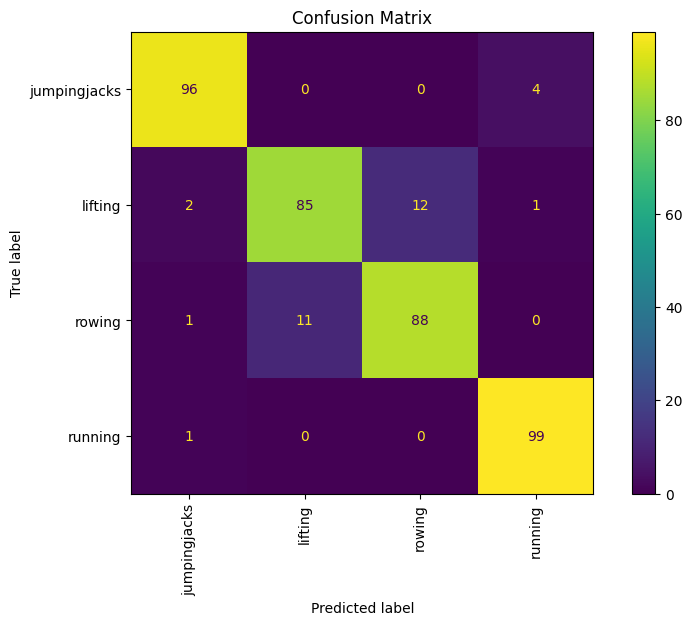

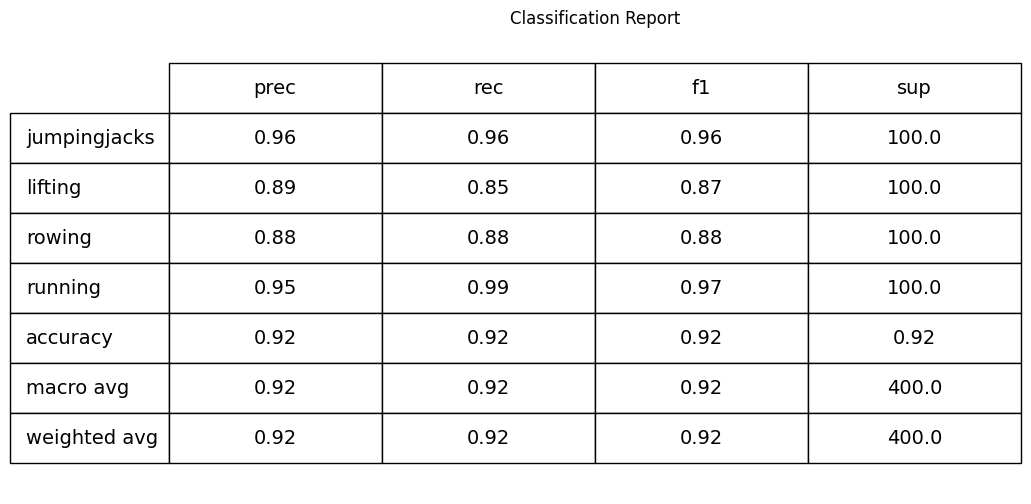

In [318]:
best = get_best_configuration(evaluate_classifiers(x_train, y_train, x_test, y_test))#
print(best)
plot_confusion_matrix(y_test, best["predictions"])
plot_classification_report(best["report"])


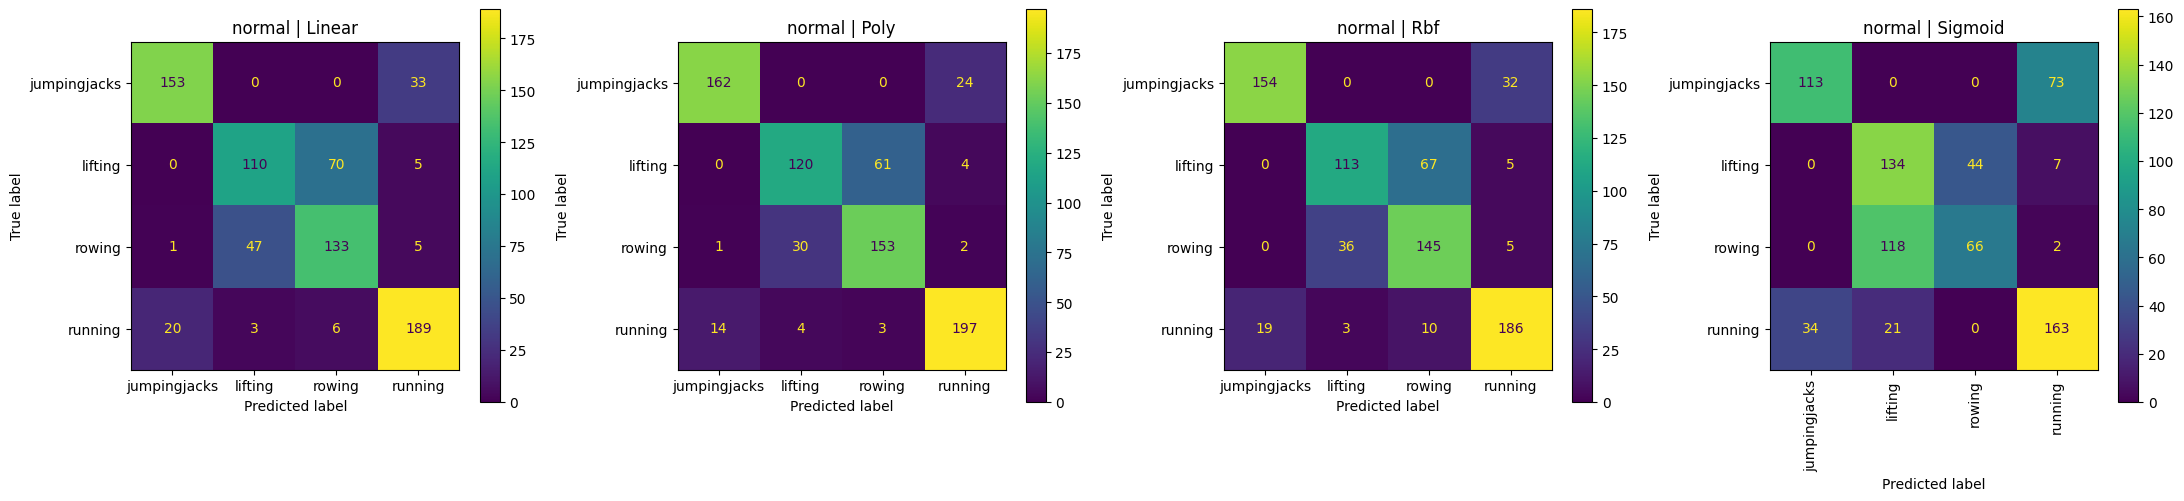

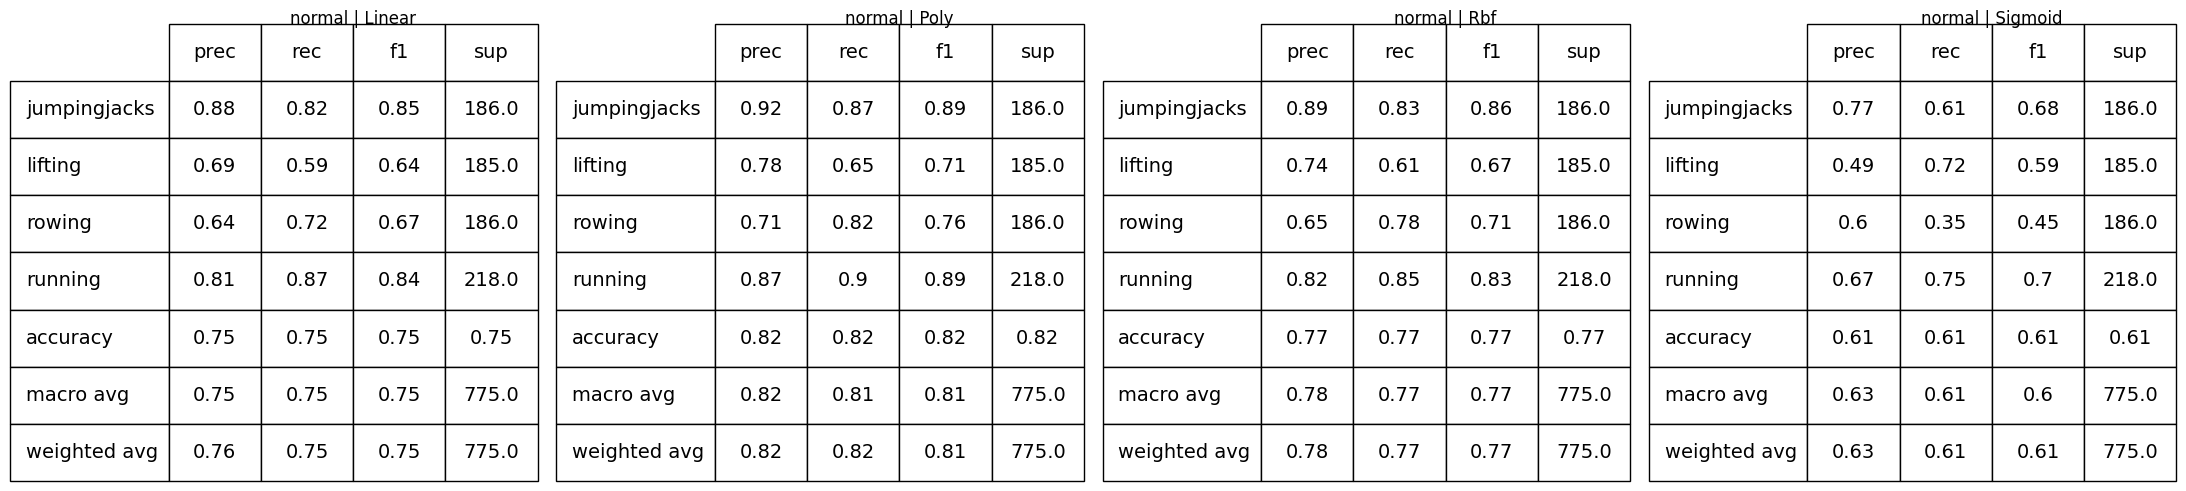

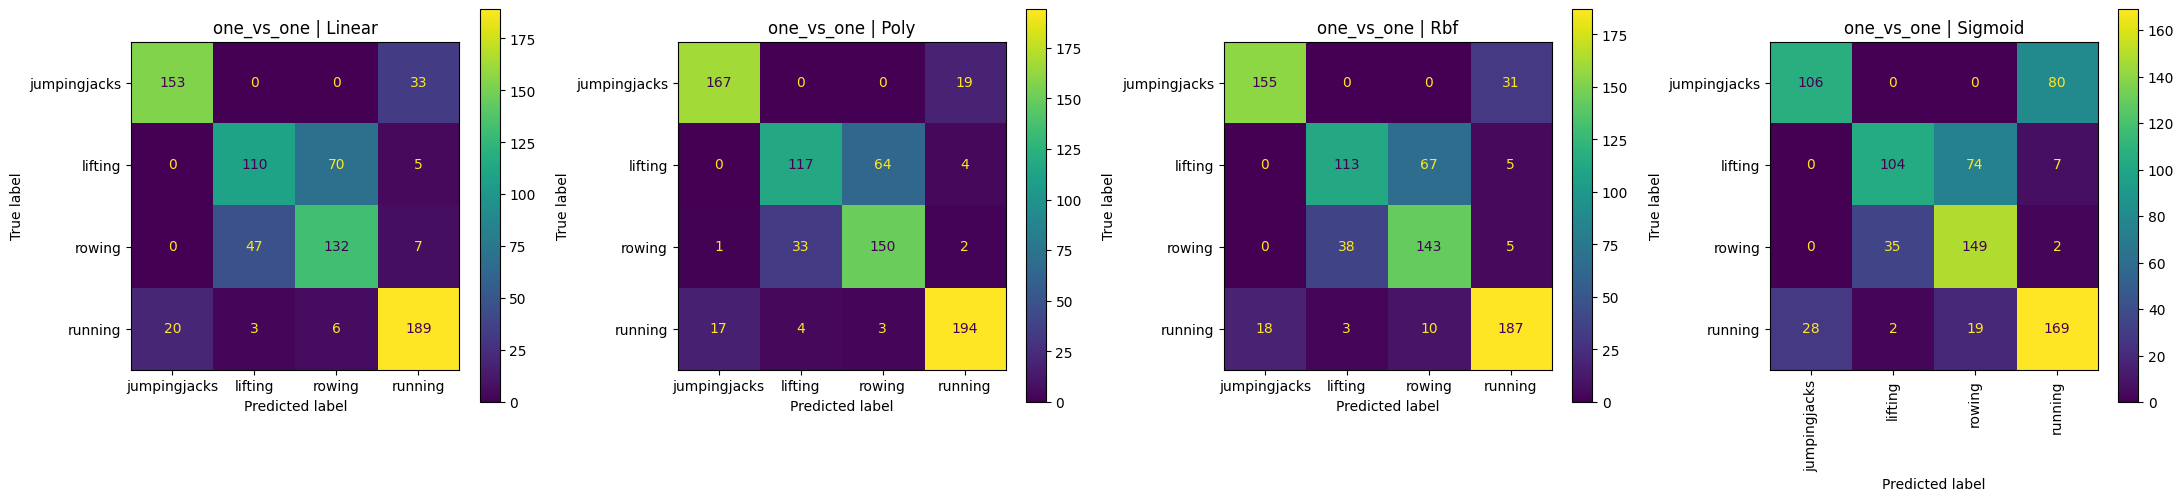

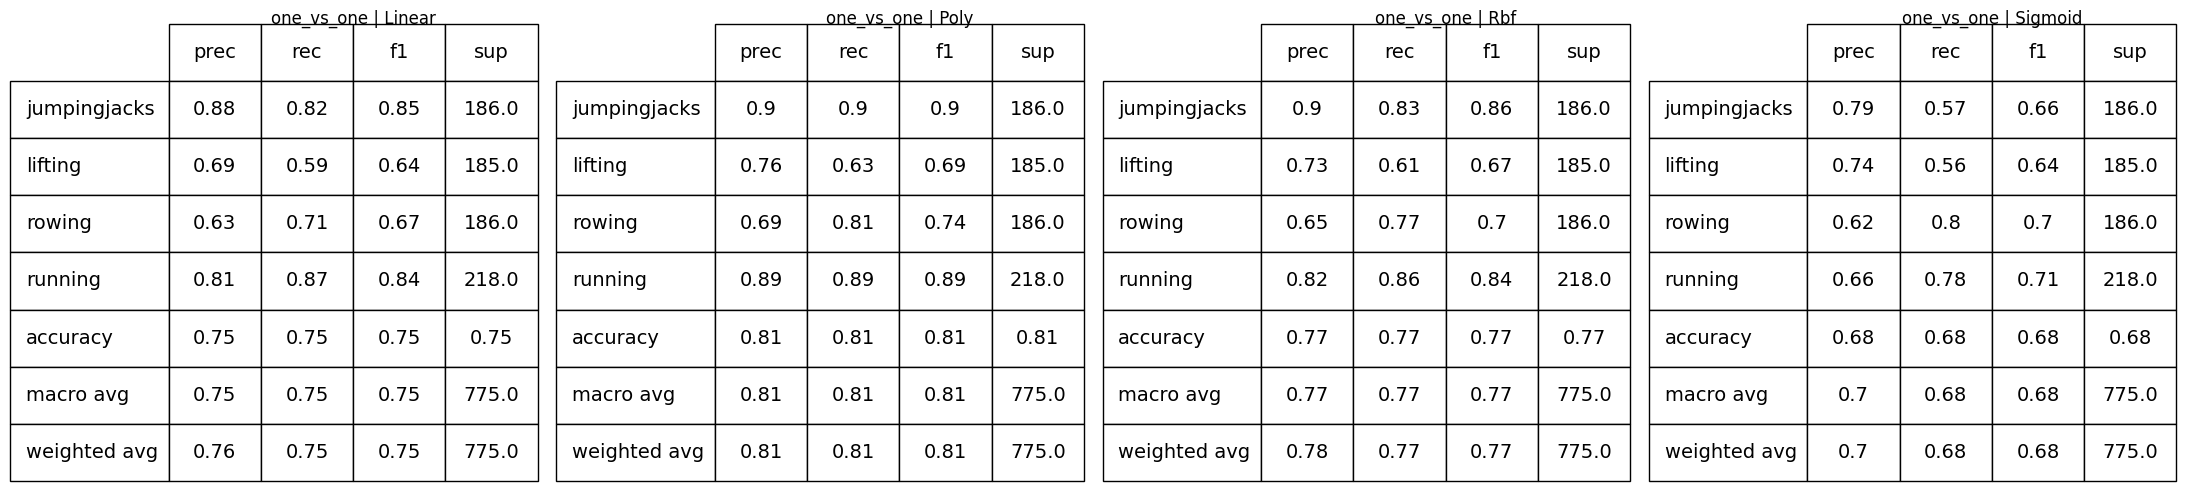

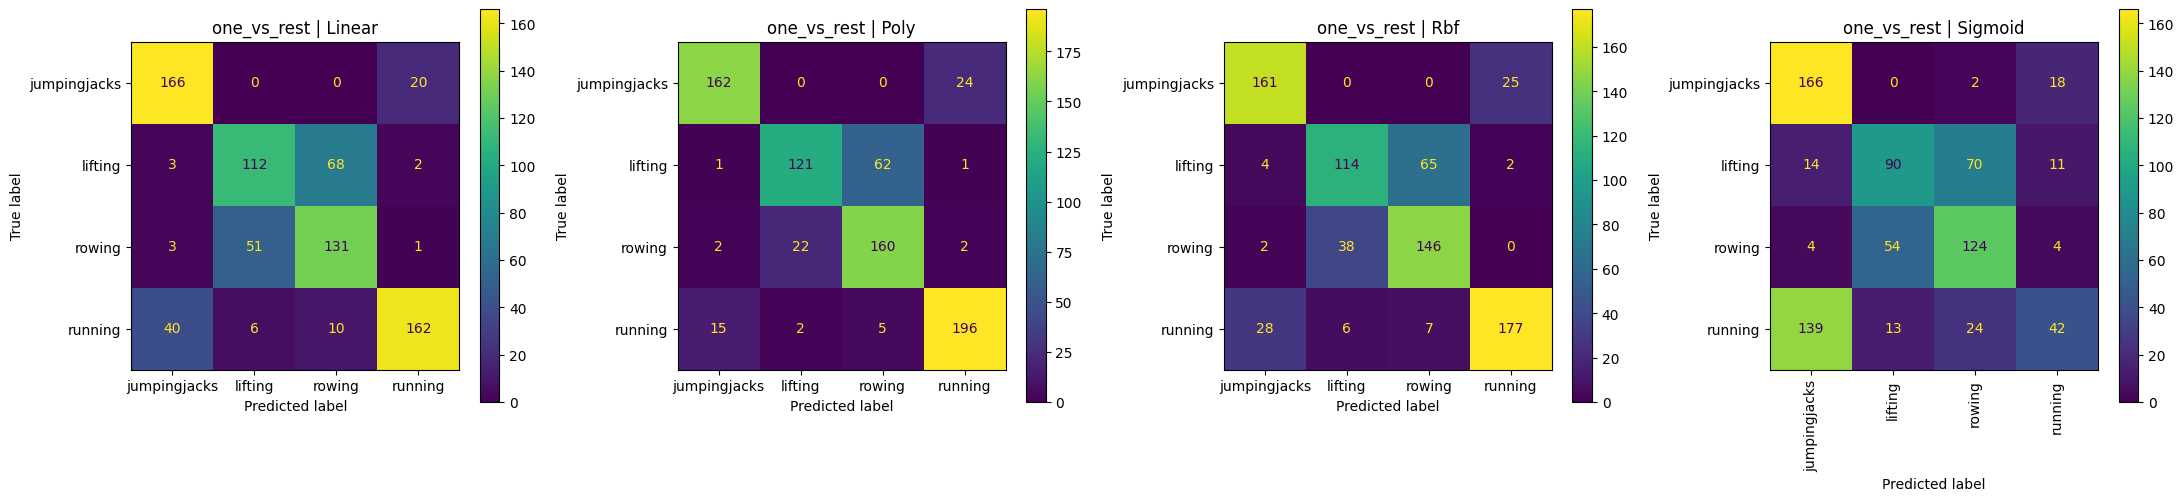

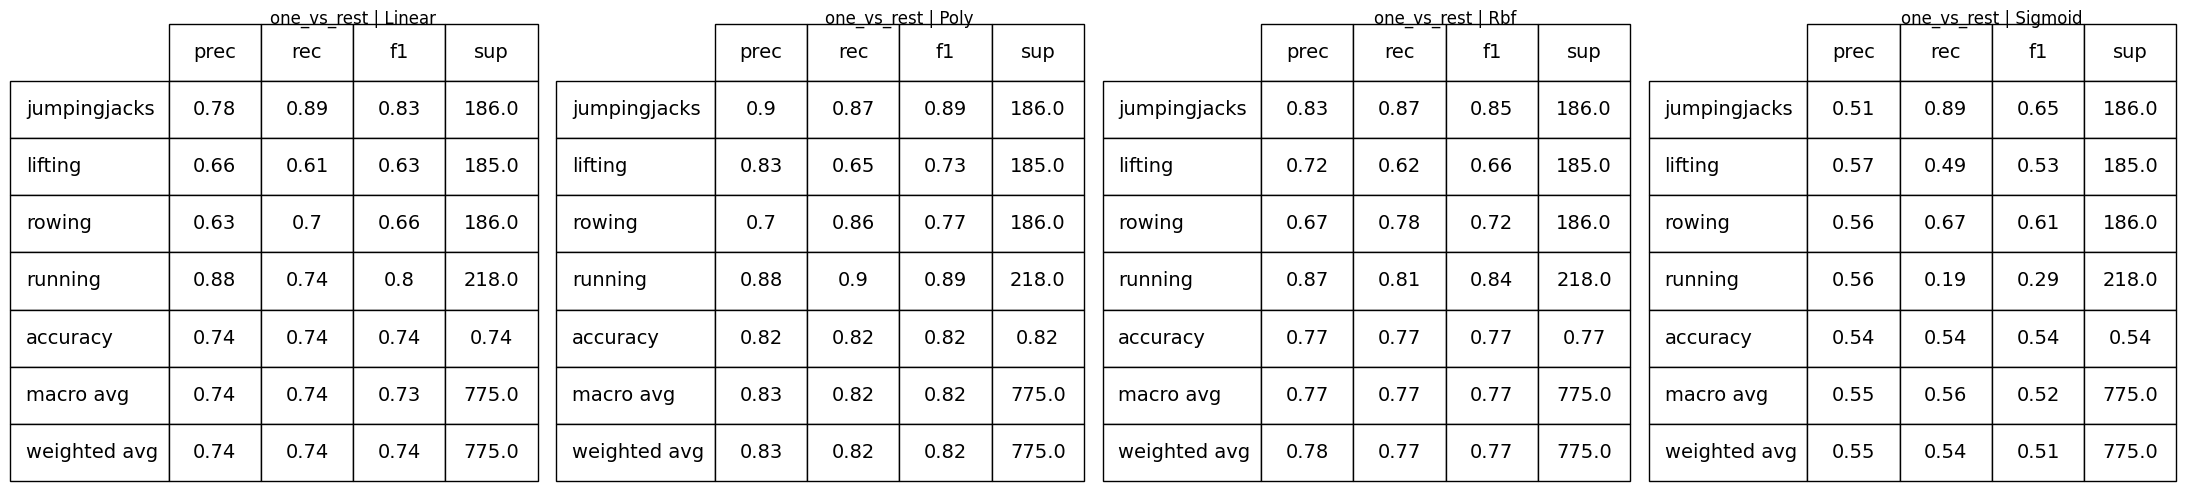

[{'strategy': 'normal',
  'kernel': 'linear',
  'classifier': SVC(kernel='linear'),
  'window_length': None,
  'feature_set': None,
  'loso': None,
  'predictions': array(['rowing', 'rowing', 'jumpingjacks', 'running', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'running', 'running', 'running',
         'running', 'running', 'jumpingjacks', 'jumpingjacks', 'rowing',
         'rowing', 'rowing', 'rowing', 'rowing', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'rowing', 'rowing', 'rowing', 'rowing', 'rowing', 'running',
         'running', 'running', 'running', 'running', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'running',
         'running', 'running', 'running', 'lifting', 'lifting', 'lifting',
         'lifting', 'jumpingjacks', 'jumpingjacks', 

In [97]:
evaluate_classifiers(x_train, y_train, x_test, y_test, print_confusion_matrices=True, print_classification_reports=True)

### Complete Date varying Window Length ###


### Length 1 ###
- Window Length 1
- Complete Features 
- Sample Rate 20Hz and 100Hz
- Sensor Placement Hand and Pocket

In [98]:
WINDOW_LENGTH = 1

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

classifier_train_data = transform_windows_to_features(train_windows)
classifier_test_data = transform_windows_to_features(test_windows)

standard_scaled_train = perform_standard_scaling(classifier_train_data, classifier_train_data)
normalized_train = perform_normalization(standard_scaled_train, standard_scaled_train )

standard_scaled_test = perform_standard_scaling(classifier_train_data, classifier_test_data)
normalized_test = perform_normalization(standard_scaled_train, standard_scaled_test)

In [99]:
x_train_1 = normalized_test.drop(columns=["activity"])
y_train_1 = normalized_test["activity"]

x_test_1 = normalized_test.drop(columns=["activity"])
y_test_1 = normalized_test["activity"]

In [27]:
evaluate_classifiers(x_train_1, y_train_1, x_test_1, y_test_1)


[{'strategy': 'normal',
  'kernel': 'linear',
  'classifier': SVC(kernel='linear'),
  'window_length': None,
  'feature_set': None,
  'loso': None,
  'predictions': array(['rowing', 'rowing', 'rowing', ..., 'rowing', 'rowing', 'rowing'],
        shape=(1567,), dtype=object),
  'report':               precision    recall  f1-score      support
  jumpingjacks   0.786486  0.773936  0.780161   376.000000
  lifting        0.783784  0.618667  0.691505   375.000000
  rowing         0.706150  0.824468  0.760736   376.000000
  running        0.781385  0.820455  0.800443   440.000000
  accuracy       0.761966  0.761966  0.761966     0.761966
  macro avg      0.764451  0.759381  0.758211  1567.000000
  weighted avg   0.765131  0.761966  0.759979  1567.000000,
  'accuracy': 0.7619655392469687,
  'macro_f1': 0.7582114323258224},
 {'strategy': 'normal',
  'kernel': 'poly',
  'classifier': SVC(kernel='poly'),
  'window_length': None,
  'feature_set': None,
  'loso': None,
  'predictions': array(['row

### Length 3 ###
- Window Length 3
- Complete Features 
- Sample Rate 20Hz and 100Hz
- Sensor Placement Hand and Pocket

In [100]:
WINDOW_LENGTH = 3

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

classifier_train_data = transform_windows_to_features(train_windows)
classifier_test_data = transform_windows_to_features(test_windows)

standard_scaled_train = perform_standard_scaling(classifier_train_data, classifier_train_data)
normalized_train = perform_normalization(standard_scaled_train, standard_scaled_train )

standard_scaled_test = perform_standard_scaling(classifier_train_data, classifier_test_data)
normalized_test = perform_normalization(standard_scaled_train, standard_scaled_test)

In [101]:
x_train_3 = normalized_test.drop(columns=["activity"])
y_train_3 = normalized_test["activity"]

x_test_3 = normalized_test.drop(columns=["activity"])
y_test_3 = normalized_test["activity"]

In [30]:
evaluate_classifiers(x_train_3, y_train_3, x_test_3, y_test_3)

[{'strategy': 'normal',
  'kernel': 'linear',
  'classifier': SVC(kernel='linear'),
  'window_length': None,
  'feature_set': None,
  'loso': None,
  'predictions': array(['rowing', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'running', 'jumpingjacks', 'running', 'jumpingjacks', 'lifting',
         'lifting', 'lifting', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'rowing', 'rowing', 'rowing',
         'jumpingjacks', 'running', 'running', 'running', 'jumpingjacks',
         'running', 'running', 'lifting', 'lifting', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'rowing', 'rowing', 'rowing',
         'rowing', 'rowing', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'running', 'running', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'lifting', 'lifting', 'lifting',
         'rowing', 'rowing', 'rowing', 'lifting', 'lifting', 

###  Length 4 ###
- Window Length 4
- Complete Features 
- Sample Rate 20Hz and 100Hz
- Sensor Placement Hand and Pocket

In [102]:
WINDOW_LENGTH = 4

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

classifier_train_data = transform_windows_to_features(train_windows)
classifier_test_data = transform_windows_to_features(test_windows)

standard_scaled_train = perform_standard_scaling(classifier_train_data, classifier_train_data)
normalized_train = perform_normalization(standard_scaled_train, standard_scaled_train )

standard_scaled_test = perform_standard_scaling(classifier_train_data, classifier_test_data)
normalized_test = perform_normalization(standard_scaled_train, standard_scaled_test)

In [103]:
x_train_4 = normalized_test.drop(columns=["activity"])
y_train_4 = normalized_test["activity"]

x_test_4 = normalized_test.drop(columns=["activity"])
y_test_4 = normalized_test["activity"]

In [33]:
evaluate_classifiers(x_train_4, y_train_4, x_test_4, y_test_4)

[{'strategy': 'normal',
  'kernel': 'linear',
  'classifier': SVC(kernel='linear'),
  'window_length': None,
  'feature_set': None,
  'loso': None,
  'predictions': array(['rowing', 'jumpingjacks', 'jumpingjacks', 'running',
         'jumpingjacks', 'jumpingjacks', 'rowing', 'lifting',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'rowing', 'lifting',
         'jumpingjacks', 'running', 'jumpingjacks', 'jumpingjacks',
         'running', 'running', 'lifting', 'lifting', 'jumpingjacks',
         'jumpingjacks', 'rowing', 'rowing', 'rowing', 'rowing',
         'jumpingjacks', 'jumpingjacks', 'running', 'running', 'running',
         'jumpingjacks', 'jumpingjacks', 'lifting', 'lifting', 'rowing',
         'rowing', 'lifting', 'lifting', 'rowing', 'rowing', 'lifting',
         'lifting', 'rowing', 'rowing', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'running', 'running',
         'jumpingjacks

### Length 5 ###

In [104]:
WINDOW_LENGTH = 5

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

classifier_train_data = transform_windows_to_features(train_windows)
classifier_test_data = transform_windows_to_features(test_windows)

standard_scaled_train = perform_standard_scaling(classifier_train_data, classifier_train_data)
normalized_train = perform_normalization(standard_scaled_train, standard_scaled_train )

standard_scaled_test = perform_standard_scaling(classifier_train_data, classifier_test_data)
normalized_test = perform_normalization(standard_scaled_train, standard_scaled_test)

In [105]:
x_train_5 = normalized_test.drop(columns=["activity"])
y_train_5 = normalized_test["activity"]

x_test_5 = normalized_test.drop(columns=["activity"])
y_test_5 = normalized_test["activity"]

In [170]:
evaluate_classifiers(x_train_5, y_train_5, x_test_5, y_test_5)

normal | Linear | Accuracy: 0.8381 | F1 Macro: 0.8356
normal | Poly | Accuracy: 0.6763 | F1 Macro: 0.6469
normal | Rbf | Accuracy: 0.8237 | F1 Macro: 0.8192
normal | Sigmoid | Accuracy: 0.5719 | F1 Macro: 0.5725
one_vs_one | Linear | Accuracy: 0.8489 | F1 Macro: 0.8465
one_vs_one | Poly | Accuracy: 0.6906 | F1 Macro: 0.6823
one_vs_one | Rbf | Accuracy: 0.8633 | F1 Macro: 0.8610
one_vs_one | Sigmoid | Accuracy: 0.5612 | F1 Macro: 0.5595
one_vs_rest | Linear | Accuracy: 0.8058 | F1 Macro: 0.8046
one_vs_rest | Poly | Accuracy: 0.7302 | F1 Macro: 0.7275
one_vs_rest | Rbf | Accuracy: 0.8273 | F1 Macro: 0.8219
one_vs_rest | Sigmoid | Accuracy: 0.5000 | F1 Macro: 0.5014


## Compare Window Length ##

In [106]:
# Window length 1, 2, 3, 4, 5
results = []

print("Results for Window =  1")
results.extend(evaluate_classifiers(x_train_1, y_train_1, x_test_1, y_test_1, window_length=1))
print("Results for Window =  2")
results.extend(evaluate_classifiers(x_train, y_train, x_test, y_test, window_length=2))
print("Results for Window =  3")
results.extend(evaluate_classifiers(x_train_3, y_train_3, x_test_3, y_test_3, window_length=3))
print("Results for Window =  4")
results.extend(evaluate_classifiers(x_train_4, y_train_4, x_test_4, y_test_4, window_length=4))  
print("Results for Window =  5")
results.extend(evaluate_classifiers(x_train_5, y_train_5, x_test_5, y_test_5, window_length=5))

get_best_configuration(results)


Results for Window =  1
Results for Window =  2
Results for Window =  3
Results for Window =  4
Results for Window =  5


{'strategy': 'one_vs_rest',
 'kernel': 'poly',
 'classifier': OneVsRestClassifier(estimator=SVC(kernel='poly')),
 'window_length': 2,
 'feature_set': None,
 'loso': None,
 'predictions': array(['rowing', 'rowing', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'running', 'running', 'running',
        'running', 'running', 'jumpingjacks', 'jumpingjacks', 'rowing',
        'rowing', 'rowing', 'rowing', 'rowing', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'rowing', 'rowing', 'rowing', 'rowing', 'rowing', 'running',
        'running', 'running', 'running', 'running', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'running',
        'running', 'running', 'running', 'lifting', 'lifting', 'lifting',
        'lifting', 'jumpingjacks', 

## Sample Rate 100 Hz ##


- Window Length 2
- Complete Features 
- Sample Rate 100Hz
- Sensor Placement Hand and Pocket

In [321]:
WINDOW_LENGTH = 2

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

In [190]:

train_windows_100 = [w for w in train_windows if w["sample"].iloc[0] == 100]
test_windows_100 = [w for w in test_windows if w["sample"].iloc[0] == 100]

classifier_train_data_100 = transform_windows_to_features(train_windows_100)
classifier_test_data_100 = transform_windows_to_features(test_windows_100)

standard_scaled_train_100 = perform_standard_scaling(classifier_train_data_100, classifier_train_data_100)
normalized_train_100 = perform_normalization(standard_scaled_train_100, standard_scaled_train_100)

standard_scaled_test_100 = perform_standard_scaling(classifier_test_data_100, classifier_test_data_100)
normalized_test_100 = perform_normalization(standard_scaled_test_100, standard_scaled_test_100)

In [191]:
x_train_100 = normalized_test_100.drop(columns=["activity"])
y_train_100 = normalized_test_100["activity"]

x_test_100 = normalized_test_100.drop(columns=["activity"])
y_test_100 = normalized_test_100["activity"]

In [192]:
get_best_configuration(run_feature_sets(feature_sets_loso, x_train_100, y_train_100, x_test_100, y_test_100, window_length=2, kernels=["poly", "linear", "rbf"]))


Evaluating with feature set: all_features
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq
Evaluating with feature set: only_acc_no_strength


{'strategy': 'normal',
 'kernel': 'poly',
 'classifier': SVC(kernel='poly'),
 'window_length': 2,
 'feature_set': 'only_acc',
 'loso': None,
 'predictions': array(['jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'rowing', 'lifting', 'running', 'running', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'rowing', 'rowing', 'rowing',
        'jumpingjacks', 'jumpingjacks', 'lifting', 'lifting', 'lifting',
        'lifting', 'lifting', 'running', 'running', 'jumpingjacks',
        'jumpingjacks', 'rowing', 'rowing', 'running', 'running', 'rowing',
        'lifting', 'lifting', 'rowing', 'rowing', 'rowing', 'rowing',
        'lifting', 'lifting', 'rowing', 'running', 'running', 'rowing',
        'rowing', 'running', 'running', 'jumpingjacks', 'rowing',
        'lifting', 'rowing', 'rowing', 'rowing', 'rowing', 'running',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'lifting',
        'lifting', 'jumpingjacks', 'jumpingjacks', 'running', 'running',


In [196]:
WINDOW_LENGTH = 2

train_windows = create_time_windows(train_recordings, WINDOW_LENGTH)
test_windows = create_time_windows(test_recording, WINDOW_LENGTH)

In [198]:

train_windows_100 = train_windows
test_windows_100 = [w for w in test_windows if w["sample"].iloc[0] == 100]

classifier_train_data_100 = transform_windows_to_features(train_windows_100)
classifier_test_data_100 = transform_windows_to_features(test_windows_100)

standard_scaled_train_100 = perform_standard_scaling(classifier_train_data_100, classifier_train_data_100)
normalized_train_100 = perform_normalization(standard_scaled_train_100, standard_scaled_train_100)

standard_scaled_test_100 = perform_standard_scaling(classifier_test_data_100, classifier_test_data_100)
normalized_test_100 = perform_normalization(standard_scaled_test_100, standard_scaled_test_100)

In [199]:
x_train_100 = normalized_test_100.drop(columns=["activity"])
y_train_100 = normalized_test_100["activity"]

x_test_100 = normalized_test_100.drop(columns=["activity"])
y_test_100 = normalized_test_100["activity"]

In [200]:
get_best_configuration(run_feature_sets(feature_sets_loso, x_train_100, y_train_100, x_test_100, y_test_100, window_length=2, kernels=["poly", "linear", "rbf"]))


Evaluating with feature set: all_features
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq
Evaluating with feature set: only_acc_no_strength


{'strategy': 'one_vs_rest',
 'kernel': 'poly',
 'classifier': OneVsRestClassifier(estimator=SVC(kernel='poly')),
 'window_length': 2,
 'feature_set': 'only_acc_with_gyro_freq',
 'loso': None,
 'predictions': array(['rowing', 'rowing', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'rowing', 'rowing', 'rowing', 'rowing', 'lifting',
        'running', 'running', 'running', 'running', 'running',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'jumpingjacks', 'rowing', 'rowing', 'rowing', 'rowing', 'rowing',
        'rowing', 'rowing', 'rowing', 'rowing', 'jumpingjacks',
        'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
        'running', 'jumpingjacks', 'lifting', 'lifting', 'lifting',
        'lift

## Sample Rate 20 Hz ##


- Window Length 2
- Complete Features 
- Sample Rate 20Hz
- Sensor Placement Hand and Pocket

In [193]:
train_windows_20 = [w for w in train_windows if w["sample"].iloc[0] == 20]
test_windows_20 = [w for w in test_windows if w["sample"].iloc[0] == 20]

classifier_train_data_20 = transform_windows_to_features(train_windows_20)
classifier_test_data_20 = transform_windows_to_features(test_windows_20)

standard_scaled_train_20 = perform_standard_scaling(classifier_train_data_20, classifier_train_data_20)
normalized_train_20 = perform_normalization(standard_scaled_train_20, standard_scaled_train_20)

standard_scaled_test_20 = perform_standard_scaling(classifier_test_data_20, classifier_test_data_20)
normalized_test_20 = perform_normalization(standard_scaled_test_20, standard_scaled_test_20)

In [194]:
x_train_20 = normalized_train_20.drop(columns=["activity"])
y_train_20 = normalized_train_20["activity"]

x_test_20 = normalized_test_20.drop(columns=["activity"])
y_test_20 = normalized_test_20["activity"]

In [195]:
get_best_configuration(run_feature_sets(feature_sets_loso, x_train_20, y_train_20, x_test_20, y_test_20, window_length=2, kernels=["poly", "linear", "rbf"]))


Evaluating with feature set: all_features
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq
Evaluating with feature set: only_acc_no_strength


{'strategy': 'one_vs_one',
 'kernel': 'poly',
 'classifier': OneVsOneClassifier(estimator=SVC(kernel='poly')),
 'window_length': 2,
 'feature_set': 'only_acc',
 'loso': None,
 'predictions': array(['jumpingjacks', 'jumpingjacks', 'lifting', 'lifting',
        'jumpingjacks', 'jumpingjacks', 'running', 'lifting', 'running',
        'jumpingjacks', 'jumpingjacks', 'rowing', 'rowing', 'lifting',
        'lifting', 'lifting', 'running', 'jumpingjacks', 'jumpingjacks',
        'running', 'jumpingjacks', 'jumpingjacks', 'rowing', 'rowing',
        'lifting', 'rowing', 'rowing', 'running', 'rowing', 'rowing',
        'running', 'running', 'jumpingjacks', 'running', 'running',
        'running', 'jumpingjacks', 'rowing', 'rowing', 'rowing', 'rowing',
        'running', 'running', 'jumpingjacks', 'jumpingjacks', 'rowing',
        'rowing', 'jumpingjacks', 'jumpingjacks', 'lifting', 'lifting',
        'jumpingjacks', 'jumpingjacks', 'rowing', 'rowing', 'lifting',
        'lifting', 'rowing', 'ro

## Feature Test ##
Based on Best Result one vs one rbf for Window Length 2 


In [207]:
feature_sets = {
    "all_features": [],
    "no_freq": ["acc_dom_freq", "dom_gyro_freq"],
    "no_strength": ["acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std"],
    "only_acc": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq"],
    "only_acc_no_strength" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq", "acc_strenght_mean", "acc_strenght_std"],
    "only_gyro": ["acc_x_mean", "acc_x_std", "acc_x_min", "acc_x_max", "acc_y_mean", "acc_y_std", "acc_y_min", "acc_y_max", "acc_z_mean", "acc_z_std", "acc_z_min", "acc_z_max", "acc_strenght_mean", "acc_strenght_std", "acc_dom_freq"],
    "only_mean_std": ["acc_x_min", "acc_x_max", "acc_y_min", "acc_y_max", "acc_z_min", "acc_z_max", "gyro_x_min", "gyro_x_max", "gyro_y_min", "gyro_y_max", "gyro_z_min", "gyro_z_max", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std", "acc_dom_freq", "dom_gyro_freq"],
    "only_min_max": ["acc_x_mean", "acc_x_std", "acc_y_mean", "acc_y_std", "acc_z_mean", "acc_z_std", "gyro_x_mean", "gyro_x_std", "gyro_y_mean", "gyro_y_std", "gyro_z_mean", "gyro_z_std", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std", "acc_dom_freq", "dom_gyro_freq"],
    "only_acc_no_freq": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq", "acc_dom_freq"],
    "only_acc_only_mean_std": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "acc_x_min", "acc_x_max", "acc_y_min", "acc_y_max", "acc_z_min", "acc_z_max", "acc_dom_freq", "dom_gyro_freq"],
    "only_acc_only_min_max": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq","acc_x_mean", "acc_x_std", "acc_y_mean", "acc_y_std", "acc_z_mean", "acc_z_std", "acc_strenght_mean", "acc_strenght_std", "acc_dom_freq"],
    "only_acc_no_freq_no_strength": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "dom_gyro_freq", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std","acc_dom_freq"],
    "only_acc_with_gyro_freq_and_strength" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max"],
    "only_acc_with_gyro_freq" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std"]}   

In [159]:
run_feature_sets(feature_sets, x_train, y_train, x_test, y_test, window_length=2)

Evaluating with feature set: all_features
Evaluating with feature set: no_freq
Evaluating with feature set: no_strength
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_strength
Evaluating with feature set: only_gyro
Evaluating with feature set: only_mean_std
Evaluating with feature set: only_min_max
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_only_mean_std
Evaluating with feature set: only_acc_only_min_max
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq


[{'strategy': 'normal',
  'kernel': 'linear',
  'classifier': SVC(kernel='linear'),
  'window_length': 2,
  'feature_set': 'all_features',
  'loso': None,
  'predictions': array(['rowing', 'rowing', 'jumpingjacks', 'running', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'running', 'running', 'running',
         'running', 'running', 'jumpingjacks', 'jumpingjacks', 'rowing',
         'rowing', 'rowing', 'rowing', 'rowing', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'jumpingjacks',
         'rowing', 'rowing', 'rowing', 'rowing', 'rowing', 'running',
         'running', 'running', 'running', 'running', 'jumpingjacks',
         'jumpingjacks', 'jumpingjacks', 'jumpingjacks', 'running',
         'running', 'running', 'running', 'lifting', 'lifting', 'lifting',
         'lifting', 'jumpingjacks', 'jumpingj

In [160]:
get_best_configuration(run_feature_sets(feature_sets, x_train, y_train, x_test, y_test, window_length=2))

Evaluating with feature set: all_features
Evaluating with feature set: no_freq
Evaluating with feature set: no_strength
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_strength


KeyboardInterrupt: 

## Compare Feature Sets for different Window Lengths ##

In [319]:
results = []
print("Comparing different feature sets for Window Length = 1")
results.extend(run_feature_sets(feature_sets, x_train_1, y_train_1, x_test_1, y_test_1, window_length=1))
print("Comparing different feature sets for Window Length = 2")
results.extend(run_feature_sets(feature_sets, x_train, y_train, x_test, y_test, window_length=2))
print("Comparing different feature sets for Window Length = 3")
results.extend(run_feature_sets(feature_sets, x_train_3, y_train_3, x_test_3, y_test_3, window_length=3))
print("Comparing different feature sets for Window Length = 4")
results.extend(run_feature_sets(feature_sets, x_train_4, y_train_4, x_test_4, y_test_4, window_length=4))
print("Comparing different feature sets for Window Length = 5")
results.extend(run_feature_sets(feature_sets, x_train_5, y_train_5, x_test_5, y_test_5, window_length=5))

#et_best_configuration(results)
results


Comparing different feature sets for Window Length = 1
Evaluating with feature set: all_features
Evaluating strategy: normal
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_one
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_rest
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating with feature set: no_freq
Evaluating strategy: normal
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_one
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_rest
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kern

KeyboardInterrupt: 

In [165]:
for r in results:
    if r["accuracy"] > 0.84:
        print(f"Window Length: {r['window_length']} | Feature Set: {r['feature_set']} | Strategy: {r['strategy']} | Kernel: {r['kernel']} | Accuracy: {r['accuracy']:.4f} | Macro F1: {r['macro_f1']:.4f}")

Window Length: 2 | Feature Set: only_acc | Strategy: normal | Kernel: poly | Accuracy: 0.8877 | Macro F1: 0.8863
Window Length: 2 | Feature Set: only_acc | Strategy: one_vs_one | Kernel: poly | Accuracy: 0.8619 | Macro F1: 0.8585
Window Length: 2 | Feature Set: only_acc | Strategy: one_vs_rest | Kernel: poly | Accuracy: 0.8619 | Macro F1: 0.8592
Window Length: 2 | Feature Set: only_acc_no_strength | Strategy: normal | Kernel: poly | Accuracy: 0.8671 | Macro F1: 0.8668
Window Length: 2 | Feature Set: only_acc_no_strength | Strategy: one_vs_one | Kernel: poly | Accuracy: 0.8477 | Macro F1: 0.8458
Window Length: 2 | Feature Set: only_acc_no_freq | Strategy: normal | Kernel: poly | Accuracy: 0.8568 | Macro F1: 0.8555
Window Length: 2 | Feature Set: only_acc_only_mean_std | Strategy: normal | Kernel: poly | Accuracy: 0.8413 | Macro F1: 0.8377
Window Length: 2 | Feature Set: only_acc_with_gyro_freq_and_strength | Strategy: normal | Kernel: poly | Accuracy: 0.8594 | Macro F1: 0.8566
Window Le

## LOSO ##

Only run for top candidates, kernel, window length and features based on random split

Only for windows 1,2,3,4

Only for linear, rbf and poly

Only for listes features

In [201]:
feature_sets_loso = {
    "all_features": [],
    "only_acc": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq"],
    "only_acc_no_freq": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq", "acc_dom_freq"],
    "only_acc_no_freq_no_strength": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "dom_gyro_freq", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std","acc_dom_freq"],
    "only_acc_with_gyro_freq_and_strength" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max"],
    "only_acc_with_gyro_freq" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std"],
    "only_acc_no_strength" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq", "acc_strenght_mean", "acc_strenght_std"],
}   

In [205]:
results = run_for_every_loso_combination(feature_sets_loso, recordings, kernels=["poly", "linear", "rbf"])
metrics = calculate_loso_metrics(results)

Running for window length: 1 seconds
Running LOSO for person: daniel
Evaluating with feature set: all_features
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq
Evaluating with feature set: only_acc_no_strength
Running LOSO for person: felix
Evaluating with feature set: all_features
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq
Evaluating with feature set: only_acc_no_strength
Running LOSO for person: ferdi
Evaluating with feature set: all_features
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc

In [206]:
for m in metrics:
    if metrics[m]["macro_f1"] > 0.69:
        print(f"Window Length: {m[0]} | Feature Set: {m[1]} | Strategy: {m[2]} | Kernel: {m[3]} | Accuracy: {metrics[m]['accuracy']:.4f} | Macro F1: {metrics[m]['macro_f1']:.4f}")

Window Length: 2 | Feature Set: only_acc | Strategy: normal | Kernel: poly | Accuracy: 0.7193 | Macro F1: 0.6987
Window Length: 2 | Feature Set: only_acc_with_gyro_freq | Strategy: normal | Kernel: poly | Accuracy: 0.7263 | Macro F1: 0.7040


In [208]:
results_all_los = run_for_every_loso_combination(feature_sets, recordings, kernels=["poly", "linear", "rbf"])
metrics_2 = calculate_loso_metrics(results_all_los)

Running for window length: 1 seconds
Running LOSO for person: daniel
Evaluating with feature set: all_features
Evaluating with feature set: no_freq
Evaluating with feature set: no_strength
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_strength
Evaluating with feature set: only_gyro
Evaluating with feature set: only_mean_std
Evaluating with feature set: only_min_max
Evaluating with feature set: only_acc_no_freq
Evaluating with feature set: only_acc_only_mean_std
Evaluating with feature set: only_acc_only_min_max
Evaluating with feature set: only_acc_no_freq_no_strength
Evaluating with feature set: only_acc_with_gyro_freq_and_strength
Evaluating with feature set: only_acc_with_gyro_freq
Running LOSO for person: felix
Evaluating with feature set: all_features
Evaluating with feature set: no_freq
Evaluating with feature set: no_strength
Evaluating with feature set: only_acc
Evaluating with feature set: only_acc_no_strength
Evaluating with feature set: only_

In [209]:
for m in metrics_2:
    if metrics_2[m]["macro_f1"] > 0.69:
        print(f"Window Length: {m[0]} | Feature Set: {m[1]} | Strategy: {m[2]} | Kernel: {m[3]} | Accuracy: {metrics_2[m]['accuracy']:.4f} | Macro F1: {metrics_2[m]['macro_f1']:.4f}")

Window Length: 2 | Feature Set: only_acc | Strategy: normal | Kernel: poly | Accuracy: 0.7193 | Macro F1: 0.6987
Window Length: 2 | Feature Set: only_acc_with_gyro_freq | Strategy: normal | Kernel: poly | Accuracy: 0.7263 | Macro F1: 0.7040


In [320]:
results = run_for_every_loso_combination(feature_sets, recordings)
loso_metrics = calculate_loso_metrics(results)

Running for window length: 1 seconds
Running LOSO for person: daniel
Evaluating with feature set: all_features
Evaluating strategy: normal
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_one
Evaluating with kernel: linear
Evaluating with kernel: poly
Evaluating with kernel: rbf
Evaluating with kernel: sigmoid
Evaluating strategy: one_vs_rest
Evaluating with kernel: linear


KeyboardInterrupt: 

## Hyperparamter Tuning ##

Fine Tuning of the best configurations out of loso test
Top 4 configurations were:

- Window Length: 2 | Feature Set: only_acc | Strategy: one_vs_rest | Kernel: poly | Accuracy: 0.7170 | Macro F1: 0.6915
- Window Length: 2 | Feature Set: only_acc_with_gyro_freq | Strategy: one_vs_rest | Kernel: poly | Accuracy: 0.7199 | Macro F1: 0.6934
- Window Length: 3 | Feature Set: only_acc_with_gyro_freq | Strategy: one_vs_one | Kernel: linear | Accuracy: 0.7126 | Macro F1: 0.6919
- Window Length: 4 | Feature Set: only_acc_with_gyro_freq | Strategy: one_vs_one | Kernel: linear | Accuracy: 0.7105 | Macro F1: 0.6916
- Window Length: 4 | Feature Set: only_acc_with_gyro_freq | Strategy: one_vs_rest | Kernel: poly | Accuracy: 0.7217 | Macro F1: 0.6928

In [152]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", 0.1, 0.01, 0.001]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale", 0.1, 0.01],
        "coef0": [0.0, 0.5, 1.0, 2.0]
    }
]

In [151]:
param_grid_test = [
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale", 0.1, 0.01]
    }
]

In [150]:
param_grid_v2 = [
    {
        "estimator__kernel": ["linear"],
        "estimator__C": [0.1, 1, 10, 100]
    },
    {
        "estimator__kernel": ["rbf"],
        "estimator__C": [0.1, 1, 10, 100],
        "estimator__gamma": ["scale", 0.1, 0.01, 0.001]
    },
    {
        "estimator__kernel": ["poly"],
        "estimator__C": [0.1, 1, 10],
        "estimator__degree": [2, 3, 4],
        "estimator__gamma": ["scale", 0.1, 0.01],
        "estimator__coef0": [0.0, 0.5, 1.0, 2.0]
    }
]

In [123]:
def compare_hyperparameters(param_grid, x_train, y_train):
    grid = GridSearchCV(svm.SVC(), param_grid, cv=5, n_jobs=-1)
    grid.fit(x_train, y_train)
    
    grid.fit(x_train, y_train)
    print(grid.best_params_)
    print(grid.best_score_)

In [ ]:
def loso_grid_search(recordings, param_grid, feature_sets, window_length):
    persons = set(rec["name"] for rec in recordings)

    results = []
    for person in persons:
        print(f"Running LOSO for person: {person}")
        train_recordings, test_recording = loso_split_recordings_to_train_test(
            recordings, person)

        train_windows = create_time_windows(train_recordings, window_length)
        test_windows = create_time_windows(test_recording, window_length)

        train_features = transform_windows_to_features(train_windows)
        test_features = transform_windows_to_features(test_windows)

        standard_scaled_train = perform_standard_scaling(
            train_features, train_features)
        normalized_train = perform_normalization(
            standard_scaled_train, standard_scaled_train)

        standard_scaled_test = perform_standard_scaling(
            train_features, test_features)
        normalized_test = perform_normalization(
            standard_scaled_train, standard_scaled_test)

        x_train = normalized_train.drop(columns=feature_sets["only_acc"]).drop(columns=["activity"])
        y_train = normalized_train["activity"]
        x_test = normalized_test.drop(columns=feature_sets["only_acc"]).drop(columns=["activity"])
        y_test = normalized_test["activity"]
        
    
        grid = GridSearchCV(svm.SVC(), param_grid, cv=5, n_jobs=-1, scoring="f1_macro")
        grid.fit(x_train, y_train)
        
        best_model = grid.best_estimator_
        predictions = best_model.predict(x_test)
        
        report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

        results.append({
            "person": person,
            "best_params": grid.best_params_,
            "best_score": grid.best_score_,
            "report": report,
            "accuracy_score": report["accuracy"],
            "macro_f1_score": report["macro avg"]["f1-score"]
        })

        print(grid.best_params_)
        print(grid.best_score_)
    return results
        

In [155]:
res = loso_grid_search(recordings, param_grid, test_feature_sets_loso)

Running LOSO for person: daniel
{'C': 10, 'coef0': 1.0, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
0.7801397316954333
Running LOSO for person: felix
{'C': 10, 'coef0': 2.0, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
0.7639596276270039
Running LOSO for person: ferdi
{'C': 10, 'coef0': 0.0, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
0.8020900811764384
Running LOSO for person: georg
{'C': 10, 'coef0': 1.0, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
0.8193481848763964
Running LOSO for person: lennart
{'C': 10, 'coef0': 0.5, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
0.8194248925906639
Running LOSO for person: marcel
{'C': 10, 'coef0': 0.0, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
0.782799864759361
Running LOSO for person: maximilian
{'C': 10, 'coef0': 1.0, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
0.792635659492509
Running LOSO for person: patrick
{'C': 1, 'coef0': 2.0, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
0.7723646175357388
Running 

In [134]:
for r in res:
    if r["macro_f1_score"] > 0.69:
        print(f"Person: {r['person']} | Best Params: {r['best_params']} | Best CV Score: {r['best_score']:.4f} | Accuracy: {r['accuracy_score']:.4f} | Macro F1: {r['macro_f1_score']:.4f}")

Person: daniel | Best Params: {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'} | Best CV Score: 0.7738 | Accuracy: 0.8889 | Macro F1: 0.8519
Person: felix | Best Params: {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'} | Best CV Score: 0.7574 | Accuracy: 0.7083 | Macro F1: 0.7038
Person: ferdi | Best Params: {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'} | Best CV Score: 0.8026 | Accuracy: 0.7000 | Macro F1: 0.6994
Person: lennart | Best Params: {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'} | Best CV Score: 0.8174 | Accuracy: 0.7312 | Macro F1: 0.7100
Person: marcel | Best Params: {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'} | Best CV Score: 0.7853 | Accuracy: 0.9375 | Macro F1: 0.9368
Person: patrick | Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'} | Best CV Score: 0.7705 | Accuracy: 0.7063 | Macro F1: 0.7151
Person: thu | Best Params: {'C': 10, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'} | Best CV Score: 0.82

In [140]:
one_vs_one_results = loso_grid_search(recordings, param_grid_v2, test_feature_sets_loso)

Running LOSO for person: daniel
{'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'}
0.764526967285588
Running LOSO for person: felix
{'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'}
0.7639248214344491
Running LOSO for person: ferdi
{'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'}
0.783741482830736
Running LOSO for person: georg
{'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'}
0.807338898374755
Running LOSO for person: lennart
{'estimator__C': 100, 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}
0.8050900627403358
Running LOSO for person: marcel
{'estimator__C': 100, 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}
0.7738210888484114
Running LOSO for person: maximilian
{'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel'

In [148]:
one_vs_one_results

[{'person': 'daniel',
  'best_params': {'estimator__C': 10,
   'estimator__degree': 4,
   'estimator__gamma': 'scale',
   'estimator__kernel': 'poly'},
  'best_score': np.float64(0.764526967285588),
  'report': {'jumpingjacks': {'precision': 0.7142857142857143,
    'recall': 0.5,
    'f1-score': 0.5882352941176471,
    'support': 10.0},
   'lifting': {'precision': 1.0,
    'recall': 0.9,
    'f1-score': 0.9473684210526315,
    'support': 10.0},
   'rowing': {'precision': 0.9090909090909091,
    'recall': 1.0,
    'f1-score': 0.9523809523809523,
    'support': 10.0},
   'running': {'precision': 0.8888888888888888,
    'recall': 0.9523809523809523,
    'f1-score': 0.9195402298850575,
    'support': 42.0},
   'accuracy': 0.8888888888888888,
   'macro avg': {'precision': 0.8780663780663781,
    'recall': 0.838095238095238,
    'f1-score': 0.8518812243590721,
    'support': 72.0},
   'weighted avg': {'precision': 0.8828763828763828,
    'recall': 0.8888888888888888,
    'f1-score': 0.881951

In [149]:
res

[{'person': 'daniel',
  'best_params': {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'},
  'best_score': np.float64(0.7737547892720307),
  'report': {'jumpingjacks': {'precision': 0.7142857142857143,
    'recall': 0.5,
    'f1-score': 0.5882352941176471,
    'support': 10.0},
   'lifting': {'precision': 1.0,
    'recall': 0.9,
    'f1-score': 0.9473684210526315,
    'support': 10.0},
   'rowing': {'precision': 0.9090909090909091,
    'recall': 1.0,
    'f1-score': 0.9523809523809523,
    'support': 10.0},
   'running': {'precision': 0.8888888888888888,
    'recall': 0.9523809523809523,
    'f1-score': 0.9195402298850575,
    'support': 42.0},
   'accuracy': 0.8888888888888888,
   'macro avg': {'precision': 0.8780663780663781,
    'recall': 0.838095238095238,
    'f1-score': 0.8518812243590721,
    'support': 72.0},
   'weighted avg': {'precision': 0.8828763828763828,
    'recall': 0.8888888888888888,
    'f1-score': 0.8819518934817323,
    'support': 72.0}},
  'accuracy_score

In [145]:
for r in one_vs_rest_results:
    if r["macro_f1_score"] > 0.5:
        print(f"Person: {r['person']} | Best Params: {r['best_params']} | Best CV Score: {r['best_score']:.4f} | Accuracy: {r['accuracy_score']:.4f} | Macro F1: {r['macro_f1_score']:.4f}")

Person: daniel | Best Params: {'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'} | Best CV Score: 0.7530 | Accuracy: 0.8889 | Macro F1: 0.8519
Person: felix | Best Params: {'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'} | Best CV Score: 0.7384 | Accuracy: 0.6806 | Macro F1: 0.6788
Person: ferdi | Best Params: {'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'} | Best CV Score: 0.7815 | Accuracy: 0.6813 | Macro F1: 0.6796
Person: georg | Best Params: {'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'} | Best CV Score: 0.7944 | Accuracy: 0.6667 | Macro F1: 0.6576
Person: lennart | Best Params: {'estimator__C': 10, 'estimator__degree': 4, 'estimator__gamma': 'scale', 'estimator__kernel': 'poly'} | Best CV Score: 0.8032 | Accuracy: 0.6937 | Macro F1: 0.6670
Person: marcel | Best Param

## Final Evalutation Flow ##

In [ ]:
phase_1_grid = {
    "window_lengths": [1, 2, 3, 4, 5],
    "feature_sets": feature_sets,
    "kernels": ["linear", "rbf", "poly"],
    "sample_rates": [100, 20],
    "strategies": ["normal", "one_vs_one", "one_vs_rest"]
}

#### Phase 1: ####
Try every combination with LOSO Split

- Smaple Rate (20 Hz and 100 Hz)

- Window Lengths 1, 2, 3, 4 and 5

- All 14 Feature Sets

- 3 Kernels (linear, rbf, poly)

- 3 Strategies (normal, one vs one, one vs rest)

= 11 340 different combinations


#### Phase 2: ####
Take the top 5 configurations based on their avg macro f1 from Phase 1 results

Now test the hyperparameter configuration. 
- Test each with differnt C, gamma, degree, scale and coef0

#### Phase 3: ####
Again take the top 3 configurations based on their average macro f1 score from Phase 2 results

Compare them by their confusion matrix and classification report and select final model



### Phase 1 ###


In [6]:
window_lengths = [1, 2, 3, 4, 5]
sample_rates = [20, 100]
kernels = ["linear", "rbf", "poly"]
feature_sets = {
    "all_features": [],
    "no_freq": ["acc_dom_freq", "dom_gyro_freq"],
    "no_strength": ["acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std"],
    "only_acc": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq"],
    "only_acc_no_strength" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq", "acc_strenght_mean", "acc_strenght_std"],
    "only_gyro": ["acc_x_mean", "acc_x_std", "acc_x_min", "acc_x_max", "acc_y_mean", "acc_y_std", "acc_y_min", "acc_y_max", "acc_z_mean", "acc_z_std", "acc_z_min", "acc_z_max", "acc_strenght_mean", "acc_strenght_std", "acc_dom_freq"],
    "only_mean_std": ["acc_x_min", "acc_x_max", "acc_y_min", "acc_y_max", "acc_z_min", "acc_z_max", "gyro_x_min", "gyro_x_max", "gyro_y_min", "gyro_y_max", "gyro_z_min", "gyro_z_max", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std", "acc_dom_freq", "dom_gyro_freq"],
    "only_min_max": ["acc_x_mean", "acc_x_std", "acc_y_mean", "acc_y_std", "acc_z_mean", "acc_z_std", "gyro_x_mean", "gyro_x_std", "gyro_y_mean", "gyro_y_std", "gyro_z_mean", "gyro_z_std", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std", "acc_dom_freq", "dom_gyro_freq"],
    "only_acc_no_freq": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq", "acc_dom_freq"],
    "only_acc_only_mean_std": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "acc_x_min", "acc_x_max", "acc_y_min", "acc_y_max", "acc_z_min", "acc_z_max", "acc_dom_freq", "dom_gyro_freq"],
    "only_acc_only_min_max": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std", "dom_gyro_freq","acc_x_mean", "acc_x_std", "acc_y_mean", "acc_y_std", "acc_z_mean", "acc_z_std", "acc_strenght_mean", "acc_strenght_std", "acc_dom_freq"],
    "only_acc_no_freq_no_strength": ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "dom_gyro_freq", "acc_strenght_mean", "acc_strenght_std", "gyro_strenght_mean", "gyro_strenght_std","acc_dom_freq"],
    "only_acc_with_gyro_freq_and_strength" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max"],
    "only_acc_with_gyro_freq" : ["gyro_x_mean", "gyro_x_std", "gyro_x_min", "gyro_x_max", "gyro_y_mean", "gyro_y_std", "gyro_y_min", "gyro_y_max", "gyro_z_mean", "gyro_z_std", "gyro_z_min", "gyro_z_max", "gyro_strenght_mean", "gyro_strenght_std"]}   

In [15]:
result_phase1_loso = run_phase_1(feature_sets, recordings, kernels=kernels, window_lengths=[1, 2, 3, 4, 5], sample_rates=sample_rates, use_Loso=True)

Running LOSO for person: maximilian
Evaluating with window length: 1
Evaluating with sample rate: 20
Evaluating with feature set: all_features
Evaluating strategy: normal
Evaluating with kernel: linear
Evaluating with kernel: rbf
Evaluating with kernel: poly
Evaluating strategy: one_vs_one
Evaluating with kernel: linear
Evaluating with kernel: rbf
Evaluating with kernel: poly
Evaluating strategy: one_vs_rest
Evaluating with kernel: linear
Evaluating with kernel: rbf
Evaluating with kernel: poly
Evaluating with feature set: no_freq
Evaluating strategy: normal
Evaluating with kernel: linear
Evaluating with kernel: rbf
Evaluating with kernel: poly
Evaluating strategy: one_vs_one
Evaluating with kernel: linear
Evaluating with kernel: rbf
Evaluating with kernel: poly
Evaluating strategy: one_vs_rest
Evaluating with kernel: linear
Evaluating with kernel: rbf
Evaluating with kernel: poly
Evaluating with feature set: no_strength
Evaluating strategy: normal
Evaluating with kernel: linear
Evalua

In [34]:
loso_res_phase_1 = calculate_loso_metrics(result_phase1_loso)

len(loso_res_phase_1)

1260

In [ ]:
df_person_results = pd.DataFrame(result_phase1_loso)
person_performance = (
    df_person_results
    .groupby("loso")["macro_f1"]
    .mean()
    .sort_values(ascending=True)
)
display(person_performance)

loso
lennart       0.311724
ferdi         0.382427
felix         0.441483
vanessa       0.486757
thu           0.572919
maximilian    0.620295
marcel        0.626876
patrick       0.633365
georg         0.640067
Name: macro_f1, dtype: float64

In [43]:
rows = []

for config, metrics in loso_res_phase_1.items():
    rows.append({
        "window_length": config[0],
        "feature_set": config[1],
        "strategy": config[2],
        "kernel": config[3],
        "sample_rate": config[4],
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "predictions": metrics["predictions"],
        "y_test": metrics["y_test"],
        "reports": metrics["reports"]
    })

df_results = pd.DataFrame(rows)
top_10_df = df_results.sort_values(
    by="macro_f1",
    ascending=False
).head(5)
display(top_10_df)

,window_length,feature_set,strategy,kernel,sample_rate,accuracy,macro_f1,predictions,y_test,reports
407,2,only_acc,normal,poly,100,0.712923,0.694928,"[running, rowing, rowing, rowing, rowing, jump...","[lifting, lifting, lifting, lifting, lifting, ...","[[precision, recall, f1-score, support], [prec..."
497,2,only_acc_with_gyro_freq,normal,poly,100,0.709813,0.691487,"[running, rowing, rowing, rowing, rowing, jump...","[lifting, lifting, lifting, lifting, lifting, ...","[[precision, recall, f1-score, support], [prec..."
371,2,only_acc_with_gyro_freq,normal,poly,20,0.713056,0.682575,"[running, running, running, running, running, ...","[running, running, running, running, running, ...","[[precision, recall, f1-score, support], [prec..."
281,2,only_acc,normal,poly,20,0.711389,0.682430,"[running, running, running, running, running, ...","[running, running, running, running, running, ...","[[precision, recall, f1-score, support], [prec..."
623,3,only_acc_with_gyro_freq,normal,poly,20,0.711111,0.678935,"[running, running, running, running, running, ...","[running, running, running, running, running, ...","[[precision, recall, f1-score, support], [prec..."


### Phase 2 ###

In [73]:
params_phase_2 = [
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale", 0.1, 0.01],
        "coef0": [0.0, 0.5, 1.0, 2.0]
    }
]

In [74]:
configurations = [
    {
        "window_length": 2,
        "feature_set": "only_acc",
        "strategy": "normal",
        "kernel": "poly",
        "sample_rate": 100
    },
    {
        "window_length": 2,
        "feature_set": "only_acc_with_gyro_freq",
        "strategy": "normal",
        "kernel": "poly",
        "sample_rate": 100
    },
    {
        "window_length": 2,
        "feature_set": "only_acc_with_gyro_freq",
        "strategy": "normal",
        "kernel": "poly",
        "sample_rate": 20
    },
    {
        "window_length": 2,
        "feature_set": "only_acc",
        "strategy": "normal",
        "kernel": "poly",
        "sample_rate": 20
    },
    {
        "window_length": 3,
        "feature_set": "only_acc_with_gyro_freq",
        "strategy": "normal",
        "kernel": "poly",
        "sample_rate": 20
    }
]

In [80]:
from sklearn.model_selection import ParameterGrid
def compare_hyperparamters_for_configurations(configurations, recordings, param_grid, feature_sets):
    results = []
    persons = set(rec["name"] for rec in recordings)
    for config in configurations:
        print(f"Running config: {config}")
        for p in persons:
            print(f"Running for person: {p}")
            train_recordings, test_recording = loso_split_recordings_to_train_test(
                recordings, p)
            train_windows = create_time_windows(
                train_recordings, config["window_length"])
            test_windows = create_time_windows(
                test_recording, config["window_length"])

            train_windows_rate = [
                w for w in train_windows if w["sample"].iloc[0] == config["sample_rate"]]
            test_windows_rate = [
                w for w in test_windows if w["sample"].iloc[0] == config["sample_rate"]]

            train_features = transform_windows_to_features(
                train_windows_rate)
            test_features = transform_windows_to_features(
                test_windows_rate)

            standard_scaled_train = perform_standard_scaling(
                train_features, train_features)
            normalized_train = perform_normalization(
                standard_scaled_train, standard_scaled_train)

            standard_scaled_test = perform_standard_scaling(
                train_features, test_features)
            normalized_test = perform_normalization(
                standard_scaled_train, standard_scaled_test)

            x_train = normalized_train.drop(
                columns=feature_sets[config["feature_set"]]).drop(columns=["activity"])
            y_train = normalized_train["activity"]
            x_test = normalized_test.drop(
                columns=feature_sets[config["feature_set"]]).drop(columns=["activity"])
            y_test = normalized_test["activity"]
            
            for param in ParameterGrid(param_grid):
                model = svm.SVC(**param)
                model.fit(x_train, y_train)
                predictions = model.predict(x_test)
                report = classification_report(
                y_test, predictions, output_dict=True, zero_division=0)
                
                results.append({
                "loso": p,
                "window_length": config["window_length"],
                "feature_set": config["feature_set"],
                "strategy": config["strategy"],
                "kernel": param["kernel"],
                "sample_rate": config["sample_rate"],
                "report": report,
                "predictions": predictions,
                "y_test": y_test,
                "accuracy": report["accuracy"],
                "macro_f1": report["macro avg"]["f1-score"],
                "params": param
            })
    return results    


In [81]:
hyper_result = compare_hyperparamters_for_configurations(configurations, recordings, params_phase_2, feature_sets)

Running config: {'window_length': 2, 'feature_set': 'only_acc', 'strategy': 'normal', 'kernel': 'poly', 'sample_rate': 100}
Running for person: maximilian
Running for person: ferdi
Running for person: vanessa
Running for person: felix
Running for person: georg
Running for person: patrick
Running for person: thu
Running for person: lennart
Running for person: marcel
Running config: {'window_length': 2, 'feature_set': 'only_acc_with_gyro_freq', 'strategy': 'normal', 'kernel': 'poly', 'sample_rate': 100}
Running for person: maximilian
Running for person: ferdi
Running for person: vanessa
Running for person: felix
Running for person: georg
Running for person: patrick
Running for person: thu
Running for person: lennart
Running for person: marcel
Running config: {'window_length': 2, 'feature_set': 'only_acc_with_gyro_freq', 'strategy': 'normal', 'kernel': 'poly', 'sample_rate': 20}
Running for person: maximilian
Running for person: ferdi
Running for person: vanessa
Running for person: felix


In [89]:
len(hyper_result)

4860

In [85]:

def calculate_loso_grid_metrics(results):
    metrics = {}
    for r in results:
        config_key = (
            r["window_length"],
            r["feature_set"],
            r["strategy"],
            r["sample_rate"],
            r["params"].get("C", None),
            r["params"].get("degree", None),
            r["params"].get("gamma", None),
            r["params"].get("coef0", None),
            r["params"].get("kernel", None)
        )
        if config_key not in metrics:
            metrics[config_key] = {
                "accuracy": [],
                "macro_f1": [],
                "predictions": [],
                "y_test": [],
                "reports": [],
                "param": r["params"],
                "persons": []
            }

        metrics[config_key]["accuracy"].append(r["accuracy"])
        metrics[config_key]["macro_f1"].append(r["macro_f1"])

        metrics[config_key]["predictions"].extend(r["predictions"])
        metrics[config_key]["y_test"].extend(r["y_test"])

        metrics[config_key]["reports"].append(r["report"])
        metrics[config_key]["persons"].append(r["loso"])

    for key in metrics:
        metrics[key]["accuracy"] = np.mean(metrics[key]["accuracy"])
        metrics[key]["macro_f1"] = np.mean(metrics[key]["macro_f1"])
        metrics[key]["n_persons"] = len(set(metrics[key]["persons"]))

    return metrics

In [86]:
hyper_results_combined = calculate_loso_grid_metrics(hyper_result)

In [88]:
len(hyper_results_combined)

540

In [104]:
rows = []

for config, metrics in hyper_results_combined.items():

    rows.append({
        "window_length": config[0],
        "feature_set": config[1],
        "strategy": config[2],
        "sample_rate": config[3],
        "C": config[4],
        "degree": config[5],
        "gamma": config[6],
        "coef0": config[7],
        "kernel": config[8],
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "n_persons": metrics["n_persons"],
        "params": metrics["param"],
        "predictions": metrics["predictions"],
        "y_test": metrics["y_test"],
        "reports": metrics["reports"]
    })

df_hyper_results = pd.DataFrame(rows)
top_3_hyper = (
    df_hyper_results
    .sort_values(by="macro_f1", ascending=False)
    .head(3)
)

display(top_3_hyper)

,window_length,feature_set,strategy,sample_rate,C,degree,gamma,coef0,kernel,accuracy,macro_f1,n_persons,params,predictions,y_test,reports
402,2,only_acc,normal,20,10.0,4,scale,0.0,poly,0.773333,0.766836,9,"{'C': 10, 'coef0': 0.0, 'degree': 4, 'gamma': ...","[running, running, running, running, running, ...","[running, running, running, running, running, ...","[{'jumpingjacks': {'precision': 0.84, 'recall'..."
420,2,only_acc,normal,20,10.0,4,scale,1.0,poly,0.766111,0.758987,9,"{'C': 10, 'coef0': 1.0, 'degree': 4, 'gamma': ...","[running, running, running, running, running, ...","[running, running, running, running, running, ...",[{'jumpingjacks': {'precision': 0.977272727272...
417,2,only_acc,normal,20,10.0,3,scale,1.0,poly,0.766806,0.757798,9,"{'C': 10, 'coef0': 1.0, 'degree': 3, 'gamma': ...","[running, running, running, running, running, ...","[running, running, running, running, running, ...",[{'jumpingjacks': {'precision': 0.897959183673...


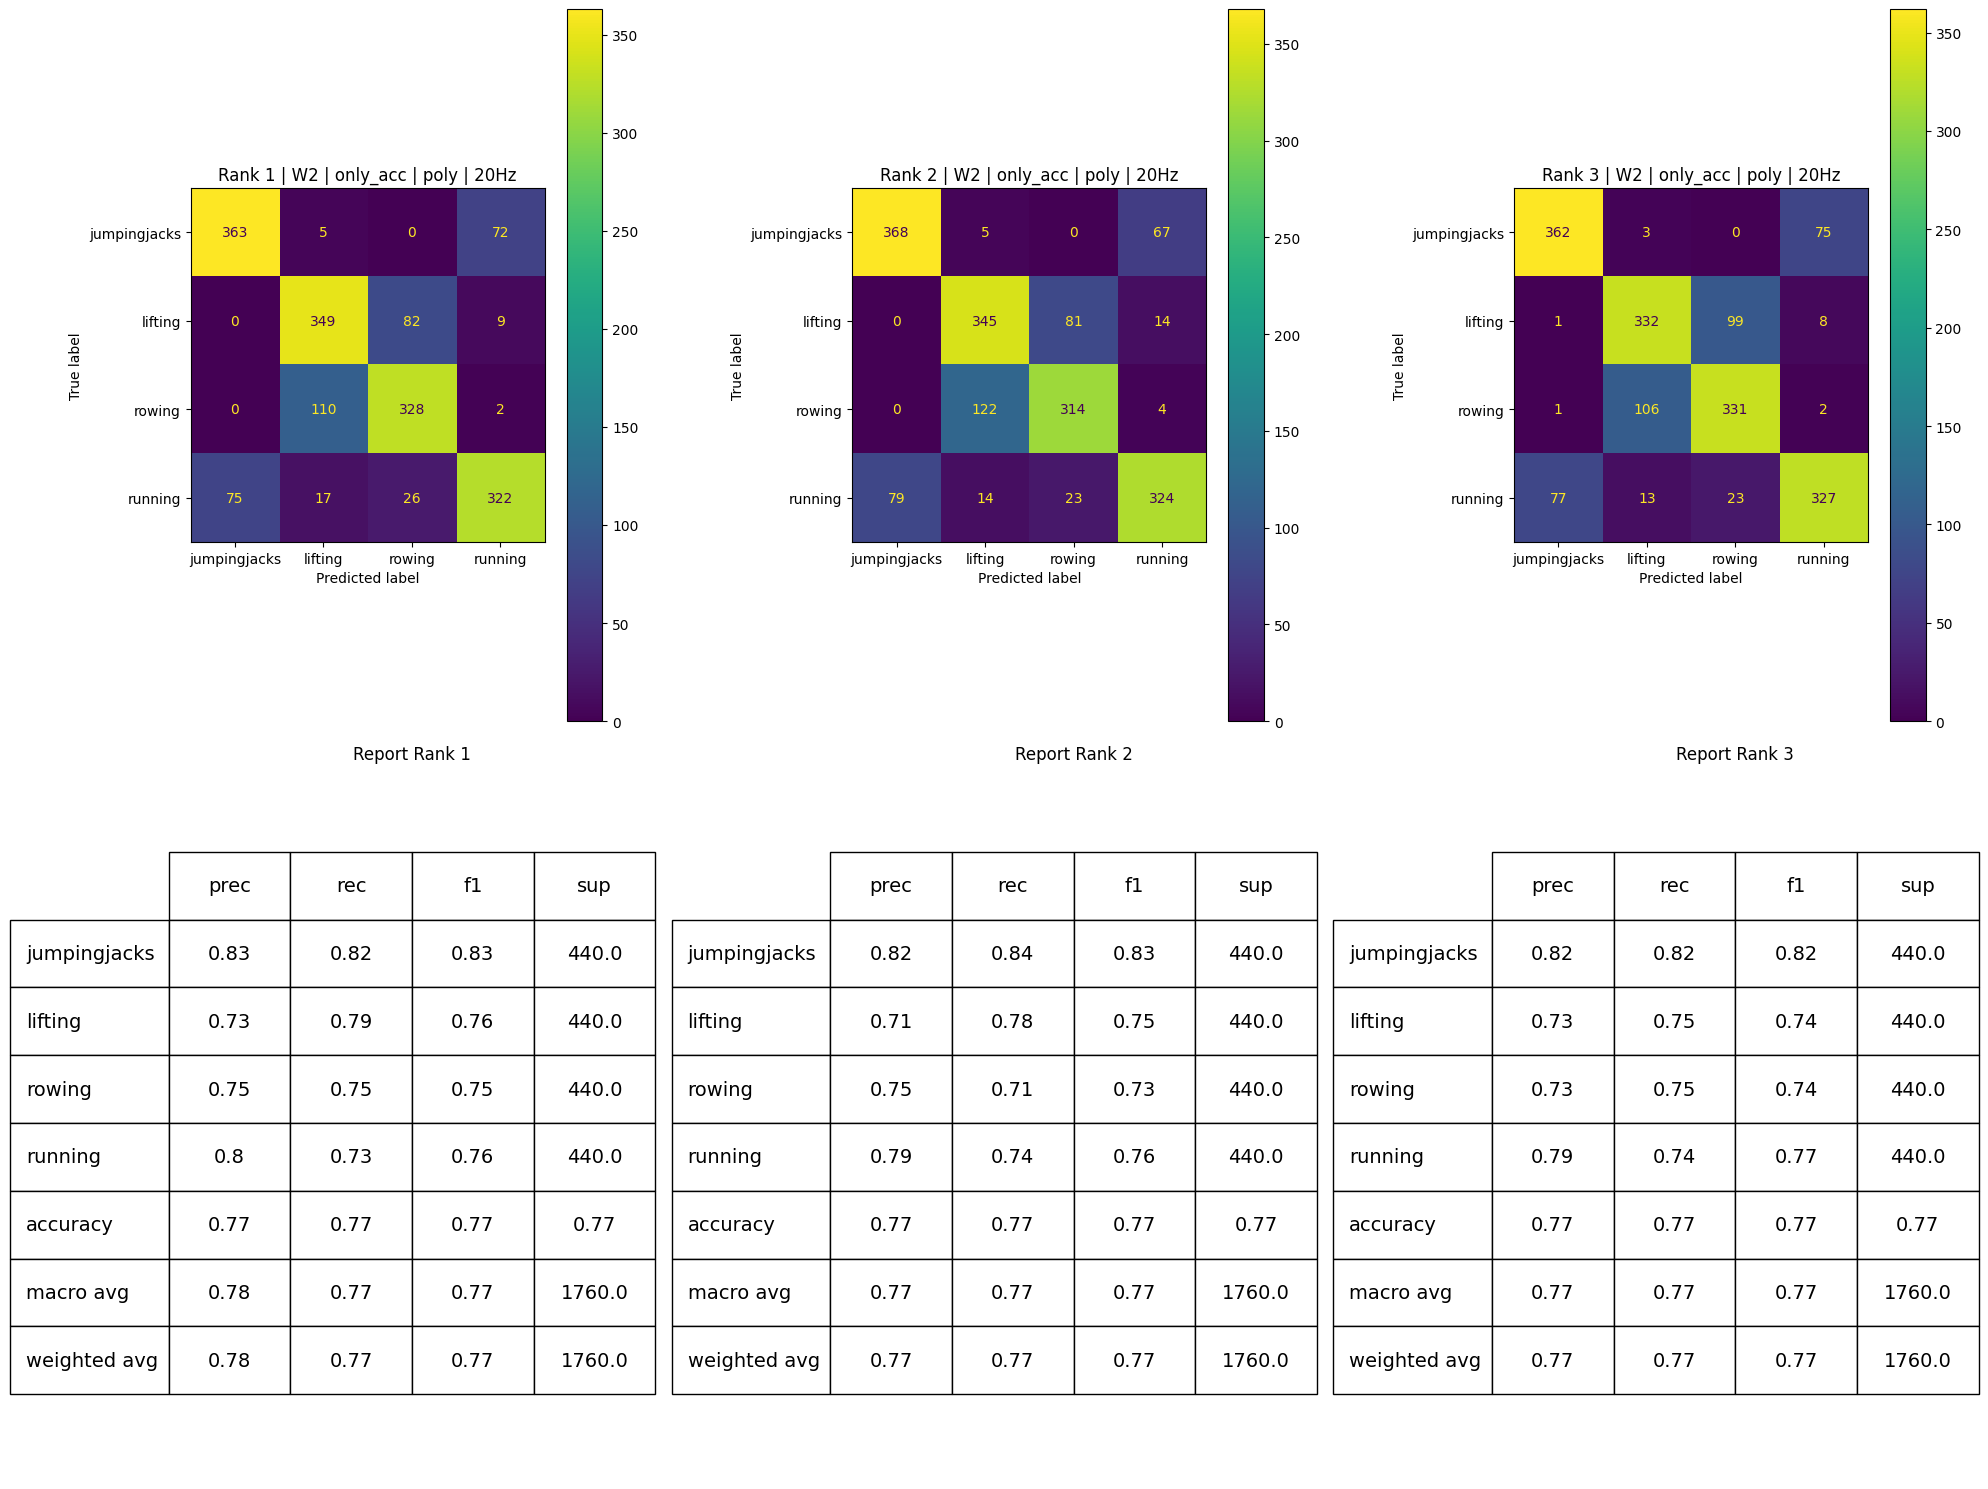

In [105]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

top_3_hyper = (
    df_hyper_results
    .sort_values(by="macro_f1", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 3, figsize=(20, 15))

for i, row in top_3_hyper.iterrows():
    title = (
        f"Rank {i+1} | W{row['window_length']} | "
        f"{row['feature_set']} | {row['kernel']} | "
        f"{row['sample_rate']}Hz"
    )

    plot_confusion_matrix(
        row["y_test"],
        row["predictions"],
        title=title,
        ax=axes[0, i]
    )

    report = classification_report(
        row["y_test"],
        row["predictions"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    plot_classification_report(
        report_df,
        title=f"Report Rank {i+1}",
        ax=axes[1, i]
    )

plt.tight_layout()
plt.show()